# Equal-Weight Baseline: Crypto Perpetual Futures

Which prediction and entry-rule configurations survive an equal-weight strategy simulation, and
how does explicit funding settlement change the selected carrier's return? This notebook reads the
frozen registry, then replays the selected carrier without registration to isolate funding cash
flows from model and allocation changes.

**Learning objectives**

- Interpret `stage='signal'` as the equal-weight allocation baseline
- Keep validation-based carrier selection separate from holdout evaluation
- Reproduce a frozen backtest without changing the results registry
- Add position-signed official funding settlements to perpetual-futures P&L

**Book reference**: Chapter 16, Strategy Simulation

**Prerequisites**: [`12_model_analysis`](12_model_analysis.ipynb) and registered validation
predictions for all configured labels

In [1]:
"""Read-only baseline analysis with an explicit funding-cashflow replay."""

import json
import sqlite3
import warnings
from collections import defaultdict
from datetime import UTC, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.registry import read_predictions
from utils.paths import get_case_study_dir, get_case_study_source_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
SEED = 42
BAR_HOURS = 8

In [3]:
set_global_seeds(SEED)
FROZEN_CASE_DIR = get_case_study_dir(CASE_STUDY, create=False)
REGISTRY_PATH = FROZEN_CASE_DIR / "run_log" / "registry.db"
SOURCE_CASE_DIR = get_case_study_source_dir(CASE_STUDY)
setup = yaml.safe_load((SOURCE_CASE_DIR / "config" / "setup.yaml").read_text())
config = get_backtest_config(CASE_STUDY)

print(f"Registry: {REGISTRY_PATH.name} (read-only analysis)")
print("Database stage value 'signal' is reported below as the equal-weight baseline.")
print(f"Costs: {config.commission_bps + config.slippage_bps:.1f} bps per leg")

Registry: registry.db (read-only analysis)
Database stage value 'signal' is reported below as the equal-weight baseline.
Costs: 5.0 bps per leg


~/ml4t/public-release-candidate/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Read the frozen baseline cohort

The baseline allocates equally across the positions admitted by each entry rule. Model training and
entry-rule variants are selected on validation only. The cohort table records one selection-adjusted
leader per label; the holdout is not queried or used here.

In [4]:
def _baseline_leaders(registry_path) -> pl.DataFrame:
    """Return the frozen equal-weight-baseline leader for each label."""
    query = """
        SELECT c.label, t.family, t.config_name, p.checkpoint_value,
               b.prediction_hash, b.backtest_hash, b.spec_json,
               c.k_variants, c.dsr_er, c.dsr_er_pvalue,
               m.sharpe, m.sharpe_ci95_lo, m.sharpe_ci95_hi, m.psr_pvalue
        FROM cohort_metrics c
        JOIN backtest_runs b ON b.backtest_hash = c.leader_hash
        JOIN backtest_metrics m USING (backtest_hash)
        JOIN prediction_sets p USING (prediction_hash)
        JOIN training_runs t USING (training_hash)
        WHERE c.cohort_type = 'stagelabel' AND c.stage = 'signal'
        ORDER BY c.label
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        return pl.read_database(query, connection)

In [5]:
leaders = _baseline_leaders(REGISTRY_PATH)
if leaders.is_empty():
    raise RuntimeError("The frozen baseline cohort is missing")

signals = [json.loads(value)["strategy"]["signal"] for value in leaders["spec_json"]]
leaders = leaders.with_columns(
    pl.Series("entry_rule", [signal["method"] for signal in signals]),
    pl.Series("top_k", [signal.get("top_k") for signal in signals], dtype=pl.Int64),
    (pl.col("family") + pl.lit("/") + pl.col("config_name")).alias("source"),
)
print(
    leaders.select(
        "label",
        "source",
        "entry_rule",
        "top_k",
        "k_variants",
        "sharpe",
        "sharpe_ci95_lo",
        "sharpe_ci95_hi",
        "dsr_er_pvalue",
    )
)

shape: (4, 9)
┌────────────┬────────────┬────────────┬───────┬───┬───────────┬───────────┬───────────┬───────────┐
│ label      ┆ source     ┆ entry_rule ┆ top_k ┆ … ┆ sharpe    ┆ sharpe_ci ┆ sharpe_ci ┆ dsr_er_pv │
│ ---        ┆ ---        ┆ ---        ┆ ---   ┆   ┆ ---       ┆ 95_lo     ┆ 95_hi     ┆ alue      │
│ str        ┆ str        ┆ str        ┆ i64   ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆       ┆   ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ fwd_dir_8h ┆ gbm/leaves ┆ equal_weig ┆ 10    ┆ … ┆ -1.239341 ┆ -2.65521  ┆ -0.029199 ┆ 0.999997  │
│            ┆ _15_binary ┆ ht_top_k   ┆       ┆   ┆           ┆           ┆           ┆           │
│ fwd_dir_8h ┆ linear/log ┆ quintile_l ┆ 20    ┆ … ┆ -1.093497 ┆ -2.437141 ┆ 0.263556  ┆ 0.999996  │
│ _3c        ┆ istic_l1_C ┆ ong_short  ┆       ┆   ┆           ┆           ┆ 

## Only the 24-hour return leader clears zero

The four label-specific leaders already include selection over their registered baseline cohorts.
Error bars describe sampling uncertainty for each leader; the effective-rank DSR p-value in the
table above addresses selection over the frozen variants.

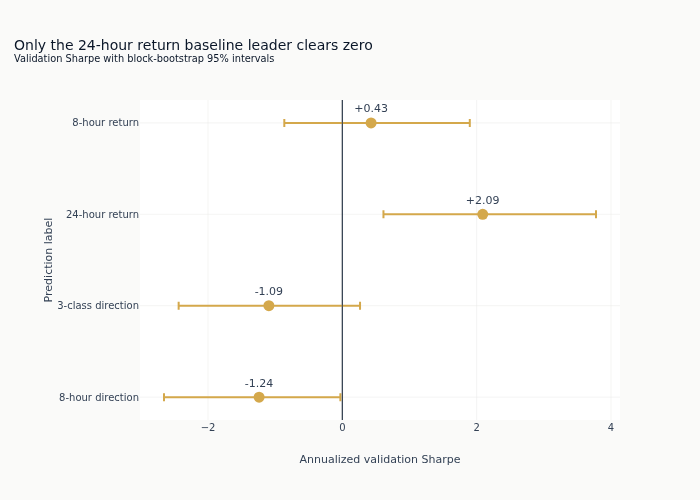

In [6]:
label_names = {
    "fwd_dir_8h": "8-hour direction",
    "fwd_dir_8h_3c": "3-class direction",
    "fwd_ret_8h": "8-hour return",
    "fwd_ret_24h": "24-hour return",
}
fig = go.Figure(
    go.Scatter(
        x=leaders["sharpe"],
        y=[label_names[value] for value in leaders["label"]],
        mode="markers+text",
        text=[f"{value:+.2f}" for value in leaders["sharpe"]],
        textposition="top center",
        marker={"size": 11, "color": COLORS["amber"]},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": (leaders["sharpe_ci95_hi"] - leaders["sharpe"]).to_list(),
            "arrayminus": (leaders["sharpe"] - leaders["sharpe_ci95_lo"]).to_list(),
        },
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Only the 24-hour return baseline leader clears zero"
        "<br><sup>Validation Sharpe with block-bootstrap 95% intervals</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Annualized validation Sharpe",
    yaxis_title="Prediction label",
    showlegend=False,
    margin={"l": 140},
)
fig.show()

## Freeze the selected carrier before touching funding

The validation winner is GBM on the 24-hour return label. Its frozen v3.0 artifact predates the
availability-clock migration and stores the legacy bar-open timestamp. The target check below
verifies that vintage against current raw prices. Prediction and price timestamps are then advanced
together to the completed 8-hour bar boundary, preserving the economic pairing without look-ahead.
Target weights are sorted by timestamp and symbol before execution so cash-constrained fills have a
deterministic order. `register=False` prevents any registry write.

In [7]:
carrier = leaders.sort("sharpe", descending=True).row(0, named=True)
CARRIER_LABEL = carrier["label"]
CARRIER_PREDICTION = carrier["prediction_hash"]
if CARRIER_LABEL != "fwd_ret_24h":
    raise RuntimeError("The frozen baseline winner changed; review the fixed 24-hour narrative")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="'Y' is deprecated", category=FutureWarning)
    validation_window = canonical_window(CASE_STUDY, CARRIER_LABEL, split="validation")
if validation_window is None:
    raise RuntimeError("No canonical validation window for the selected carrier")
validation_start, validation_end = validation_window

print(
    f"Carrier: {carrier['source']} checkpoint={carrier['checkpoint_value']} "
    f"label={CARRIER_LABEL} prediction={CARRIER_PREDICTION}"
)
print(f"Validation window: {validation_start} through {validation_end}")

Carrier: gbm/leaves_7_huber checkpoint=500 label=fwd_ret_24h prediction=fb85a7d19ce1
Validation window: 2022-01-03 through 2023-12-30


In [8]:
frozen_predictions = read_predictions(CASE_STUDY, CARRIER_PREDICTION, case_dir=FROZEN_CASE_DIR)
raw_prices = load_backtest_prices_for(
    CASE_STUDY,
    CARRIER_LABEL,
    split="validation",
    max_symbols=0,
    warmup_periods=warmup_periods_for(CASE_STUDY),
)

legacy_targets = (
    raw_prices.sort("symbol", "timestamp")
    .with_columns(
        pl.col("close").shift(-3).over("symbol").alias("end_close"),
        pl.col("timestamp").shift(-3).over("symbol").alias("end_timestamp"),
    )
    .filter(pl.col("end_timestamp") == pl.col("timestamp") + pl.duration(hours=24))
    .select(
        pl.col("timestamp").dt.replace_time_zone("UTC"),
        "symbol",
        (pl.col("end_close") / pl.col("close") - 1).alias("current_raw_target"),
    )
)
alignment = frozen_predictions.join(legacy_targets, on=["timestamp", "symbol"], how="inner")
target_correlation = alignment.select(pl.corr("y_true", "current_raw_target")).item()
if target_correlation < 0.99:
    raise ValueError("Frozen prediction timestamps do not match the legacy raw-price clock")
print(f"Frozen target/current raw-price correlation: {target_correlation:.6f}")

Frozen target/current raw-price correlation: 0.999451


In [9]:
predictions = frozen_predictions.with_columns(
    pl.col("timestamp") + pl.duration(hours=BAR_HOURS)
).filter(pl.col("timestamp").dt.date() <= validation_end)
prices = raw_prices.with_columns(pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).filter(
    pl.col("timestamp").dt.date() <= validation_end
)
funding = (
    load_funding_rates(symbols=prices["symbol"].unique().to_list())
    .with_columns(pl.col("timestamp").cast(prices.schema["timestamp"]))
    .filter(
        (pl.col("timestamp") >= prices["timestamp"].min())
        & (pl.col("timestamp") <= prices["timestamp"].max())
    )
)

print(
    f"Predictions: {predictions.height:,}; prices: {prices.height:,}; "
    f"official settlements: {funding.height:,}"
)

Predictions: 31,767; prices: 42,198; official settlements: 42,338


Repeated historical hashes collapse to one `(entry_rule, top_k)` specification. A rank-based
long-short request cannot admit more than half the available cross-section on either side. The
corrected replay therefore caps each requested side at `floor(n_assets / 2)` at every timestamp.
Frozen registry values remain visible as history, including cells generated before this repair.

In [10]:
def _carrier_cells(registry_path, prediction_hash: str) -> list[dict]:
    """Return one stored specification per semantic baseline cell."""
    query = """
        SELECT b.spec_json, m.sharpe
        FROM backtest_runs b JOIN backtest_metrics m USING (backtest_hash)
        WHERE b.stage = 'signal' AND b.prediction_hash = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        rows = connection.execute(query, (prediction_hash,)).fetchall()
    cells = {}
    for spec_json, stored_sharpe in rows:
        signal = json.loads(spec_json)["strategy"]["signal"]
        key = (signal["method"], signal.get("top_k"))
        if key not in cells or stored_sharpe > cells[key]["stored_sharpe"]:
            cells[key] = {"signal": signal, "stored_sharpe": stored_sharpe}
    return [cells[key] for key in sorted(cells)]

In [11]:
all_cells = _carrier_cells(REGISTRY_PATH, CARRIER_PREDICTION)
rank_methods = {"equal_weight_top_k", "score_weighted_top_k"}
panel_sizes = predictions.group_by("timestamp").len().rename({"len": "n_assets"})
correction_rows = []
for cell in all_cells:
    signal = cell["signal"]
    requested_k = signal.get("top_k")
    if signal["method"] in rank_methods:
        capped_timestamps = panel_sizes.filter(pl.col("n_assets") < 2 * requested_k).height
        correction_rows.append(
            {
                "entry_rule": signal["method"],
                "requested_top_k": requested_k,
                "capped_timestamps": capped_timestamps,
            }
        )

cells = all_cells
corrections = pl.DataFrame(correction_rows).sort("entry_rule", "requested_top_k")
print(
    f"Corrected baseline cells: {len(cells)}; panel size range: "
    f"{panel_sizes['n_assets'].min()} to {panel_sizes['n_assets'].max()}"
)
print(corrections)

Corrected baseline cells: 3; panel size range: 5 to 19
shape: (2, 3)
┌────────────────────┬─────────────────┬───────────────────┐
│ entry_rule         ┆ requested_top_k ┆ capped_timestamps │
│ ---                ┆ ---             ┆ ---               │
│ str                ┆ i64             ┆ i64               │
╞════════════════════╪═════════════════╪═══════════════════╡
│ equal_weight_top_k ┆ 5               ┆ 186               │
│ equal_weight_top_k ┆ 10              ┆ 1952              │
└────────────────────┴─────────────────┴───────────────────┘


## Reconstruct price P&L before adding settlements

Funding at time $t$ belongs to the position carried into $t$. Orders filled at $t$ earn or pay the
next settlement, not the current one. Temporary off-grid settlements are processed with the last
observable mark and carried position. The first oracle reconstructs the engine equity curve from
fills and marks; funding is then added as a separate cash component.

In [12]:
def _as_utc(value: datetime) -> datetime:
    """Normalize an engine timestamp to timezone-aware UTC."""
    return value.replace(tzinfo=UTC) if value.tzinfo is None else value.astimezone(UTC)

In [13]:
def _replay_inputs(result, price_frame: pl.DataFrame, funding_frame: pl.DataFrame):
    """Index fills, settlements, prices, and engine equity by UTC timestamp."""
    engine = result.engine_result
    if engine is None:
        raise RuntimeError("Funding replay requires an uncached engine result")
    fills = defaultdict(list)
    for fill in engine.fills:
        fills[_as_utc(fill.timestamp)].append(fill)
    rates = defaultdict(dict)
    for row in funding_frame.iter_rows(named=True):
        rates[_as_utc(row["timestamp"])][row["symbol"]] = float(row["funding_rate"])
    marks = defaultdict(dict)
    for row in price_frame.select("timestamp", "symbol", "close").iter_rows(named=True):
        marks[_as_utc(row["timestamp"])][row["symbol"]] = float(row["close"])
    engine_equity = {_as_utc(ts): float(value) for ts, value in engine.equity_curve}
    return fills, rates, marks, engine_equity

In [14]:
def _settlement_cash(positions, last_marks, timestamp_rates) -> float:
    """Calculate funding cash for the position carried into a settlement."""
    return sum(
        -(positions.get(symbol, 0.0) * last_marks[symbol]) * rate
        for symbol, rate in timestamp_rates.items()
        if positions.get(symbol, 0.0) != 0 and symbol in last_marks
    )

In [15]:
def _apply_fills(cash: float, positions, last_marks, timestamp_fills) -> float:
    """Apply fills after funding at a shared timestamp."""
    for fill in timestamp_fills:
        quantity = float(fill.quantity) if fill.side.value == "buy" else -float(fill.quantity)
        cash -= quantity * float(fill.price) + float(fill.commission)
        last_marks.setdefault(fill.asset, float(fill.price))
        positions[fill.asset] += quantity
        if abs(positions[fill.asset]) < 1e-12:
            del positions[fill.asset]
    return cash

In [16]:
def _replay_equity(result, price_frame: pl.DataFrame, funding_frame: pl.DataFrame):
    """Return funding-adjusted equity, cash flow, events, and reconstruction error."""
    fills, rates, marks, engine_equity = _replay_inputs(result, price_frame, funding_frame)
    cash = float(config.initial_cash)
    positions = defaultdict(float)
    cumulative_funding = 0.0
    events = 0
    settlements_processed = 0
    adjusted = []
    reconstructed = []
    last_marks = {}
    timeline = sorted(set(engine_equity) | set(rates))
    for timestamp in timeline:
        last_marks.update(marks[timestamp])
        timestamp_rates = rates.get(timestamp, {})
        settlements_processed += len(timestamp_rates)
        event_cash = _settlement_cash(positions, last_marks, timestamp_rates)
        if event_cash:
            cash += event_cash
            cumulative_funding += event_cash
            events += 1
        cash = _apply_fills(cash, positions, last_marks, fills.get(timestamp, []))
        if timestamp in engine_equity:
            marked = sum(quantity * last_marks[symbol] for symbol, quantity in positions.items())
            adjusted.append((timestamp, cash + marked))
            reconstructed.append((timestamp, cash - cumulative_funding + marked))
    error = max(abs(value - engine_equity[ts]) for ts, value in reconstructed)
    expected_settlements = sum(len(values) for values in rates.values())
    if settlements_processed != expected_settlements:
        raise RuntimeError("Funding replay did not consume every official settlement exactly once")
    return adjusted, cumulative_funding, events, error, settlements_processed

In [17]:
def _daily_sharpe(equity_curve: list[tuple[datetime, float]]) -> float:
    """Compute crypto-calendar Sharpe from end-of-day equity."""
    daily = (
        pl.DataFrame(equity_curve, schema=["timestamp", "equity"], orient="row")
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col("equity").sort_by("timestamp").last())
        .sort("date")
        .with_columns(pl.col("equity").pct_change().alias("return"))
        .filter((pl.col("date") >= validation_start) & (pl.col("date") <= validation_end))
    )
    values = daily["return"].drop_nulls().to_numpy()
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

In [18]:
def _run_registered_signal(signal: dict):
    """Run one frozen signal specification with deterministic target order."""
    spec = build_backtest_spec(
        CASE_STUDY,
        config,
        prices=prices,
        prediction_hash=CARRIER_PREDICTION,
        initial_cash=config.initial_cash,
        chapter="ch16",
        signal=signal,
    )
    weights = precompute_weights(
        predictions,
        spec,
        prices,
        label=CARRIER_LABEL,
        case_study=CASE_STUDY,
        prediction_hash=CARRIER_PREDICTION,
    ).sort("timestamp", "symbol")
    return run_backtest(
        CASE_STUDY,
        CARRIER_PREDICTION,
        spec,
        prices=prices,
        predictions=predictions,
        label=CARRIER_LABEL,
        register=False,
        precomputed_weights=weights,
        initial_cash=config.initial_cash,
        calendar=config.calendar,
    )

In [19]:
def _replay_cell(cell: dict) -> dict:
    """Add official funding settlement to one frozen signal cell."""
    signal = cell["signal"]
    result = _run_registered_signal(signal)
    curve, funding_pnl, events, reconstruction_error, settlements_processed = _replay_equity(
        result, prices, funding
    )
    return {
        "entry_rule": signal["method"],
        "top_k": signal.get("top_k"),
        "stored_sharpe": cell["stored_sharpe"],
        "price_only_sharpe": float(result.metrics["sharpe"]),
        "with_funding_sharpe": _daily_sharpe(curve),
        "funding_pnl": funding_pnl,
        "funding_events": events,
        "settlements_processed": settlements_processed,
        "reconstruction_error": reconstruction_error,
    }

In [20]:
def _validate_replay(replay_frame: pl.DataFrame, expected_settlements: int) -> None:
    """Fail closed when accounting reconstruction or settlement conservation fails."""
    errors = replay_frame["reconstruction_error"]
    if not errors.is_finite().all() or errors.max() > 1e-6:
        raise RuntimeError("Fill-and-mark reconstruction does not match engine equity")
    if replay_frame["settlements_processed"].min() != expected_settlements:
        raise RuntimeError("At least one replay missed an official funding row")

In [21]:
replay_rows = [_replay_cell(cell) for cell in cells]
replay = pl.DataFrame(replay_rows).sort("price_only_sharpe", descending=True)
_validate_replay(replay, funding.height)
print(f"Official settlement rows processed exactly once per replay: {funding.height:,}")
print(replay)
for row in replay.iter_rows(named=True):
    print(
        f"{row['entry_rule']} requested_top_k={row['top_k']}: "
        f"price_only={row['price_only_sharpe']:+.6f}, "
        f"with_funding={row['with_funding_sharpe']:+.6f}, "
        f"funding_pnl=${row['funding_pnl']:+,.2f}"
    )

Official settlement rows processed exactly once per replay: 42,338
shape: (3, 9)
┌────────────┬───────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ entry_rule ┆ top_k ┆ stored_sha ┆ price_only ┆ … ┆ funding_p ┆ funding_e ┆ settlemen ┆ reconstru │
│ ---        ┆ ---   ┆ rpe        ┆ _sharpe    ┆   ┆ nl        ┆ vents     ┆ ts_proces ┆ ction_err │
│ str        ┆ i64   ┆ ---        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ sed       ┆ or        │
│            ┆       ┆ f64        ┆ f64        ┆   ┆ f64       ┆ i64       ┆ ---       ┆ ---       │
│            ┆       ┆            ┆            ┆   ┆           ┆           ┆ i64       ┆ f64       │
╞════════════╪═══════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ equal_weig ┆ 5     ┆ 2.090074   ┆ 2.168545   ┆ … ┆ 36269.367 ┆ 2026      ┆ 42338     ┆ 2.4447e-9 │
│ ht_top_k   ┆       ┆            ┆            ┆   ┆ 627       ┆           ┆           ┆           │
│ quintile

## Funding changes the corrected cells by different amounts

The replay preserves each requested entry rule while enforcing a disjoint long-short book at every
timestamp. The difference between each pair of points is only realized funding settlement. A
positive rate debits long notional and credits short notional.

In [22]:
labels = [
    (
        f"EW requested {row['top_k']}"
        if row["entry_rule"] == "equal_weight_top_k"
        else "Quintile L/S (5 quantiles)"
    )
    for row in replay.iter_rows(named=True)
]

In [23]:
fig = go.Figure()
_ = fig.add_trace(
    go.Scatter(
        x=replay["price_only_sharpe"],
        y=labels,
        mode="markers",
        name="Price P&L net costs",
        marker={"size": 10, "color": COLORS["blue"]},
    )
)
_ = fig.add_trace(
    go.Scatter(
        x=replay["with_funding_sharpe"],
        y=labels,
        mode="markers",
        name="Including funding",
        marker={"size": 10, "color": COLORS["amber"]},
    )
)

Connecting segments show the within-cell accounting change; the zero line remains the common
performance baseline.

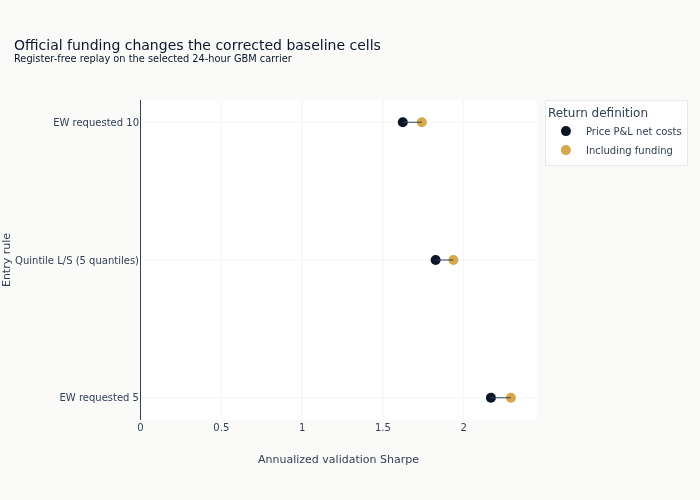

In [24]:
for index in range(replay.height):
    fig.add_shape(
        type="line",
        x0=replay["price_only_sharpe"][index],
        x1=replay["with_funding_sharpe"][index],
        y0=labels[index],
        y1=labels[index],
        line={"color": COLORS["neutral"], "width": 1},
    )
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Official funding changes the corrected baseline cells"
        "<br><sup>Register-free replay on the selected 24-hour GBM carrier</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Annualized validation Sharpe",
    yaxis_title="Entry rule",
    legend_title="Return definition",
    margin={"l": 140},
)
fig.show()

## Baseline judgment

The frozen validation cohort selects `gbm/leaves_7_huber` at checkpoint 500 on the 24-hour return
label. Its registered equal-weight top-5 baseline Sharpe is 2.09 with a 95% interval of
[0.61, 3.78]. The label-level effective-rank DSR p-value is 0.0048 across 114 frozen variants.
This selection uses no holdout information.

The register-free replay separates two return definitions. Price P&L net of commissions and
slippage reconstructs the engine before official settlement is added. The current replay also
repairs the frozen rank-based cells by dynamically capping each side at half the available panel.
The resulting values replace the overlapping or one-sided implementation in this corrected
historical replay. The corrected top-5 price-only Sharpe is +2.169; official funding raises it to
+2.292 and contributes +$36,269. Funding cannot be treated as a constant uplift because its sign
depends on the carried long and short notionals.

This notebook establishes a frozen v3.0 baseline and corrects its accounting interpretation. It
does not claim that the same carrier wins on the corrected 44-feature lineage, and it does not use
the holdout. Allocation alternatives are evaluated next.

## Key takeaways

1. Database `stage='signal'` means the equal-weight allocation baseline.
2. The frozen 24-hour GBM leader is the only label-specific baseline whose Sharpe interval clears
   zero.
3. Official funding settlements belong in total return and must be position-signed at each event.
4. Requested top-k is dynamically capped at half the available panel, repairing both early top-5
   timestamps and every top-10 timestamp without silently dropping registered cells.
5. Funding changes are strategy-dependent, so a price-only Sharpe cannot stand in for total return.
6. Every replay uses `register=False`; the frozen registry remains unchanged.

**Next**: [`14_portfolio_management`](14_portfolio_management.ipynb) compares alternative
allocation mechanisms on the validation-selected baseline carriers.